# Importing Necessary Libraries and Needed File

In [2]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

file_path = r'C:\Users\91860\Downloads\Google_dataset.xlsx'
all_sheets = pd.read_excel(file_path, sheet_name=None)
all_sheets.keys()

dict_keys(['users', 'search_queries', 'ad_clicks', 'videos', 'video_views'])

### Join Necessary Tables

In [6]:
users = all_sheets['users']
ad_clicks = all_sheets['ad_clicks']

user_ad_merge = users.merge(
    ad_clicks,
    on='user_id',
    how='inner'
)

user_ad_merge.head()

,user_id,country,device_type,signup_date,click_id,ad_id,click_date,revenue
0,1,USA,mobile,2023-01-15,1,101,2024-01-10,2.50
1,1,USA,mobile,2023-01-15,4,101,2024-01-12,2.50
2,1,USA,mobile,2023-01-15,14,101,2024-01-18,2.50
3,1,USA,mobile,2023-01-15,26,101,2024-01-23,2.50
4,2,USA,desktop,2023-02-20,2,102,2024-01-10,3.75


### Summarize Revenue by Country

In [7]:
country_revenue = (
    user_ad_merge
    .groupby('country', as_index=False)['revenue']
    .sum()
    .sort_values(by='revenue', ascending=False)
)

country_revenue

,country,revenue
8,USA,31.35
2,Canada,17.70
5,India,16.90
4,Germany,11.60
7,UK,8.80
6,Japan,4.10
0,Australia,3.30
3,France,2.70
1,Brazil,2.20


### Visualization 1: Revenue by Country

Screenshot saved: insight_1_revenue_by_country_20260620_230545.png


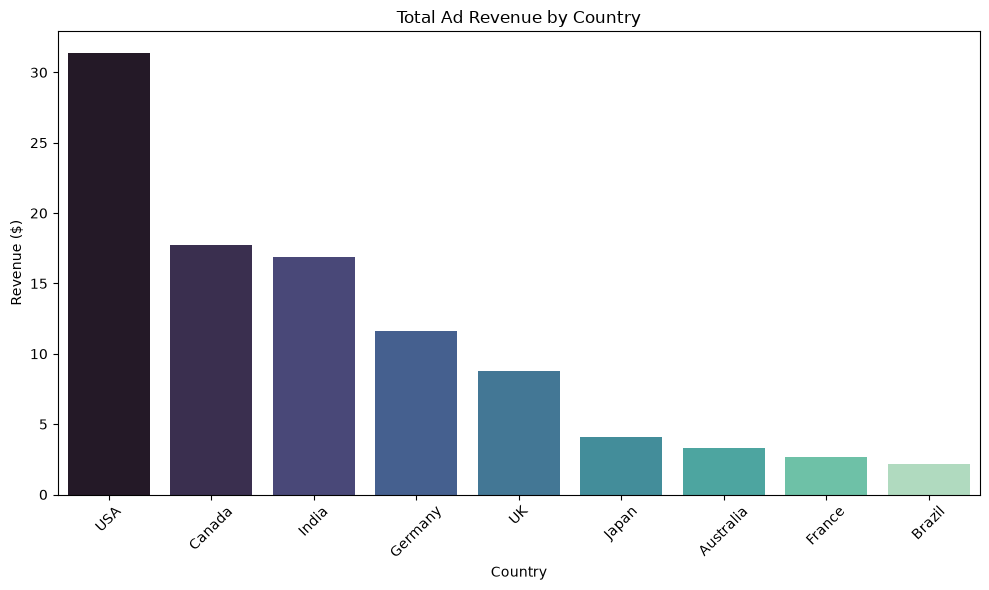

In [8]:
import os
from datetime import datetime

plt.figure(figsize=(10, 6))
sns.barplot(
    data=country_revenue,
    x='country',
    y='revenue',
    palette='mako',
    hue='country',
    legend=False
)

plt.title('Total Ad Revenue by Country')
plt.xlabel('Country')
plt.ylabel('Revenue ($)')
plt.xticks(rotation=45)
plt.tight_layout()

# Auto-screenshot
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
screenshot_path = f'insight_1_revenue_by_country_{timestamp}.png'
plt.savefig(screenshot_path, dpi=150, bbox_inches='tight')
print(f'Screenshot saved: {screenshot_path}')

plt.show()

### Insight
USA generated the highest total ad revenue, followed by Canada and India. This makes sense given the user distribution shows USA has 5 users, which is the largest share in the dataset.

---

## Question 2: Which video category gets the most watch time?

### Join Necessary Tables

In [9]:
videos = all_sheets['videos']
video_views = all_sheets['video_views']

view_video_merge = video_views.merge(
    videos,
    on='video_id',
    how='inner'
)

view_video_merge.head()

,view_id,user_id,video_id,view_date,watch_time,title,category
0,1,1,1,2024-01-10,450,Python Tutorial for Beginners,Education
1,2,2,1,2024-01-10,600,Python Tutorial for Beginners,Education
2,3,3,2,2024-01-11,320,Top 10 Travel Destinations 2024,Travel
3,4,1,3,2024-01-11,540,SQL Interview Questions,Education
4,5,4,7,2024-01-12,720,Machine Learning Basics,Education


### Summarize Watch Time by Category

In [10]:
category_watch_time = (
    view_video_merge
    .groupby('category', as_index=False)['watch_time']
    .sum()
    .sort_values(by='watch_time', ascending=False)
)

category_watch_time

,category,watch_time
0,Education,9750
4,Gaming,1900
2,Finance,1830
6,Technology,1820
7,Travel,1620
3,Food,1190
1,Entertainment,860
5,Health,770


### Visualization 2: Watch Time by Category

Screenshot saved: insight_2_watch_time_by_category_20260620_230725.png


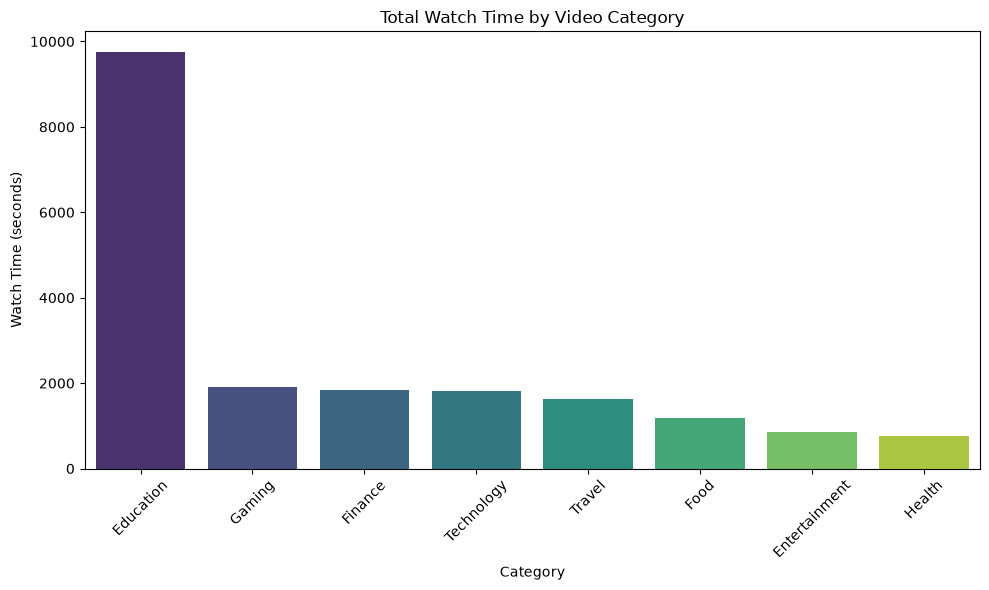

In [11]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=category_watch_time,
    x='category',
    y='watch_time',
    palette='viridis',
    hue='category',
    legend=False
)

plt.title('Total Watch Time by Video Category')
plt.xlabel('Category')
plt.ylabel('Watch Time (seconds)')
plt.xticks(rotation=45)
plt.tight_layout()

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
screenshot_path = f'insight_2_watch_time_by_category_{timestamp}.png'
plt.savefig(screenshot_path, dpi=150, bbox_inches='tight')
print(f'Screenshot saved: {screenshot_path}')

plt.show()

### Insight
Education content dominates watch time with the highest total, followed by Gaming. This indicates strong user engagement with learning and entertainment content.

---

## Question 3: Which user is most active overall?

### Calculate User Activity Metrics

In [12]:
search_queries = all_sheets['search_queries']

user_activity = (
    users[['user_id']]
    .merge(search_queries.groupby('user_id').size().rename('queries').reset_index(), on='user_id', how='left')
    .merge(ad_clicks.groupby('user_id').size().rename('clicks').reset_index(), on='user_id', how='left')
    .merge(video_views.groupby('user_id').size().rename('views').reset_index(), on='user_id', how='left')
)

for col in ['queries', 'clicks', 'views']:
    user_activity[col] = user_activity[col].fillna(0).astype(int)

user_activity['total_activity'] = user_activity[['queries', 'clicks', 'views']].sum(axis=1)
user_activity_sorted = user_activity.sort_values('total_activity', ascending=False).head(10)

user_activity_sorted

,user_id,queries,clicks,views,total_activity
0,1,14,4,4,22
1,2,3,3,4,10
3,4,3,2,3,8
2,3,2,2,3,7
4,5,2,2,3,7
5,6,2,1,3,6
6,7,1,2,2,5
9,10,1,2,2,5
7,8,1,1,2,4
8,9,1,1,2,4


### Visualization 3: Top 10 Active Users

C:\Users\91860\AppData\Local\Temp\ipykernel_8452\826344748.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


Screenshot saved: insight_3_top_active_users_20260620_230726.png


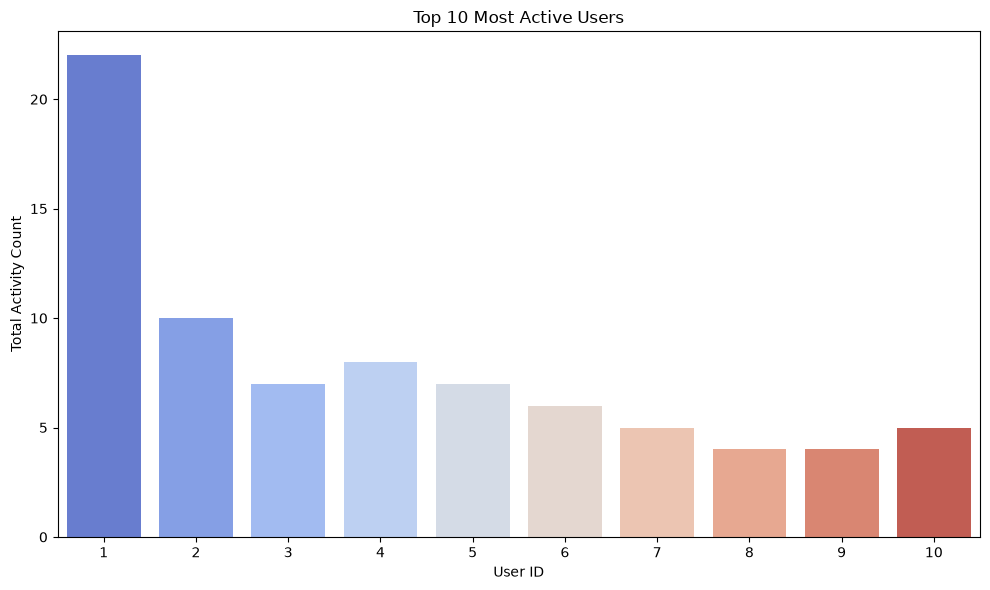

In [13]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=user_activity_sorted,
    x='user_id',
    y='total_activity',
    palette='coolwarm'
)

plt.title('Top 10 Most Active Users')
plt.xlabel('User ID')
plt.ylabel('Total Activity Count')
plt.tight_layout()

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
screenshot_path = f'insight_3_top_active_users_{timestamp}.png'
plt.savefig(screenshot_path, dpi=150, bbox_inches='tight')
print(f'Screenshot saved: {screenshot_path}')

plt.show()

### Insight
User 1 is the clear leader with 22 total activities (searches, clicks, views), significantly outpacing other users. This user shows consistent engagement across all platform features.

---

## Question 4: Which device type generates the most revenue per click?

### Calculate Revenue Metrics by Device

In [14]:
device_revenue = user_ad_merge.groupby('device_type', as_index=False).agg(
    total_revenue=('revenue', 'sum'),
    click_count=('click_id', 'count')
)

device_revenue['revenue_per_click'] = device_revenue['total_revenue'] / device_revenue['click_count']
device_revenue_sorted = device_revenue.sort_values('revenue_per_click', ascending=False)

device_revenue_sorted

,device_type,total_revenue,click_count,revenue_per_click
0,desktop,30.85,8,3.856250
2,tablet,15.10,4,3.775000
1,mobile,52.70,18,2.927778


### Visualization 4: Revenue per Click by Device

Screenshot saved: insight_4_revenue_per_device_20260620_230727.png


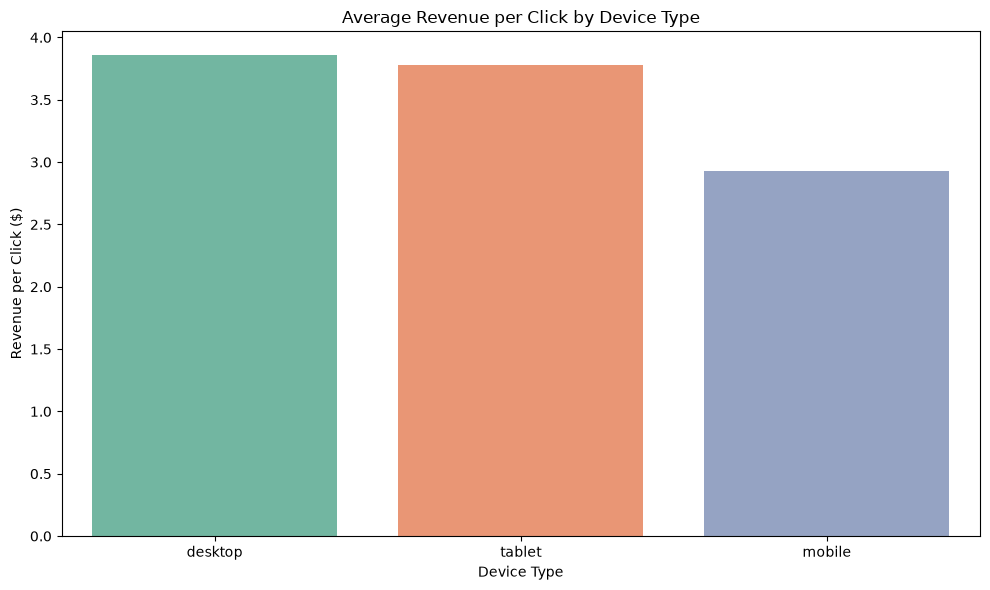

In [15]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=device_revenue_sorted,
    x='device_type',
    y='revenue_per_click',
    palette='Set2',
    hue='device_type',
    legend=False
)

plt.title('Average Revenue per Click by Device Type')
plt.xlabel('Device Type')
plt.ylabel('Revenue per Click ($)')
plt.tight_layout()

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
screenshot_path = f'insight_4_revenue_per_device_{timestamp}.png'
plt.savefig(screenshot_path, dpi=150, bbox_inches='tight')
print(f'Screenshot saved: {screenshot_path}')

plt.show()

### Insight
Desktop users generate the highest revenue per click ($3.86), slightly ahead of tablet users. Mobile users have the lowest average revenue per click, suggesting potential for better mobile ad optimization.

---

## Question 5: Which video title gets the most total watch time?

### Summarize Watch Time by Video Title

In [16]:
title_watch_time = (
    view_video_merge
    .groupby('title', as_index=False)['watch_time']
    .sum()
    .sort_values(by='watch_time', ascending=False)
    .head(10)
)

title_watch_time

,title,watch_time
9,Machine Learning Basics,2300
14,Python Tutorial for Beginners,2280
4,Data Analytics Course,1550
15,SQL Interview Questions,1510
18,Web Development Tutorial,1400
10,Mobile Gaming Tips,1250
0,AI and Future Technology,1170
3,Cryptocurrency Explained,950
12,Paris Travel Guide,900
16,Stock Market Analysis,880


### Visualization 5: Top 10 Videos by Watch Time

C:\Users\91860\AppData\Local\Temp\ipykernel_8452\227312153.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


Screenshot saved: insight_5_top_videos_watchtime_20260620_230727.png


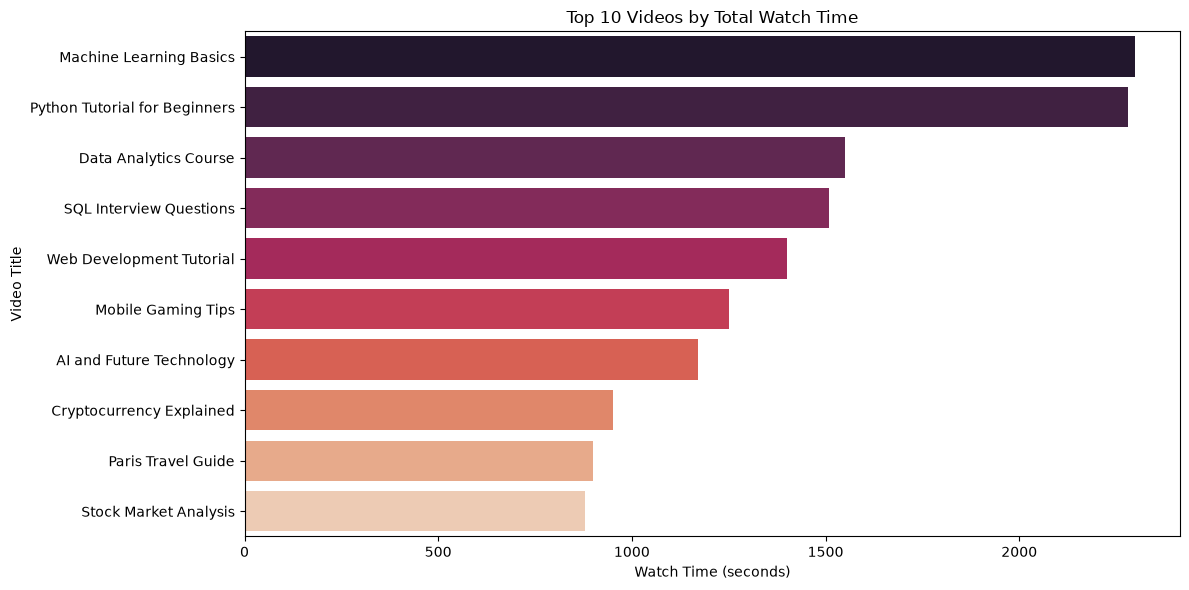

In [17]:
plt.figure(figsize=(12, 6))
sns.barplot(
    data=title_watch_time,
    x='watch_time',
    y='title',
    palette='rocket'
)

plt.title('Top 10 Videos by Total Watch Time')
plt.xlabel('Watch Time (seconds)')
plt.ylabel('Video Title')
plt.tight_layout()

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
screenshot_path = f'insight_5_top_videos_watchtime_{timestamp}.png'
plt.savefig(screenshot_path, dpi=150, bbox_inches='tight')
print(f'Screenshot saved: {screenshot_path}')

plt.show()

### Insight
"Machine Learning Basics" is the top performing video with 2,300 seconds of total watch time, followed closely by "Python Tutorial for Beginners". Tech and education content clearly resonates with users.

---

## Question 6: What search topics drive the most user engagement?

### Analyze Common Search Query Patterns

In [18]:
# Extract keywords from search queries
keywords = ['python', 'travel', 'flight', 'restaurant', 'weather', 'course', 'news', 'tech', 'hotel', 'laptop', 'cricket', 'sql']

search_data = []
for keyword in keywords:
    count = search_queries['query_text'].str.lower().str.contains(keyword, case=False, na=False).sum()
    search_data.append({'keyword': keyword, 'count': count})

query_topics = pd.DataFrame(search_data).sort_values('count', ascending=False)
query_topics = query_topics[query_topics['count'] > 0]

query_topics

,keyword,count
3,restaurant,2
2,flight,2
5,course,2
4,weather,2
6,news,2
8,hotel,2
0,python,1
1,travel,1
10,cricket,1
9,laptop,1


### Visualization 6: Top Search Topics

C:\Users\91860\AppData\Local\Temp\ipykernel_8452\2207509078.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


Screenshot saved: insight_6_search_topics_20260620_230728.png


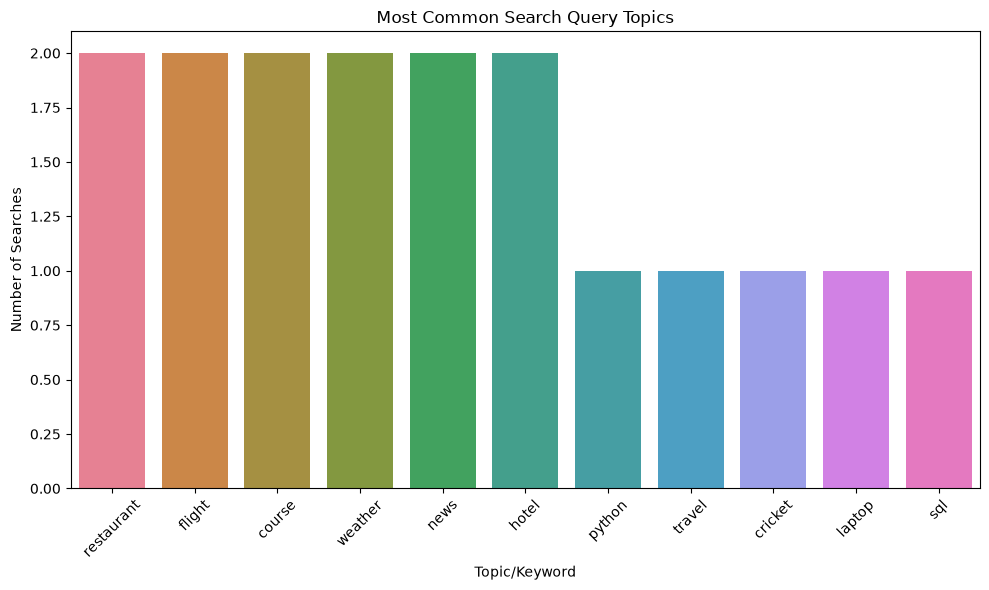

In [19]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=query_topics,
    x='keyword',
    y='count',
    palette='husl'
)

plt.title('Most Common Search Query Topics')
plt.xlabel('Topic/Keyword')
plt.ylabel('Number of Searches')
plt.xticks(rotation=45)
plt.tight_layout()

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
screenshot_path = f'insight_6_search_topics_{timestamp}.png'
plt.savefig(screenshot_path, dpi=150, bbox_inches='tight')
print(f'Screenshot saved: {screenshot_path}')

plt.show()

### Insight
Learning-focused queries (python, course, sql) appear frequently, confirming strong user interest in tech education. Travel and lifestyle topics (travel, flight, restaurant, hotel) also show significant search volume, indicating diverse user interests.